In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
# 1. Dataset Loading & Feature Selection
df = pd.read_csv('insurance.csv')

X = df.drop(columns=['charges'])
y = df['charges']

num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region']

In [ ]:
# 2. Dataset Partitioning (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# 3. Preprocessing (Scaling & Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ]
)

In [6]:
# 4 & 5. Multiple Linear Regression Model
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [7]:
# 6. Evaluation - Linear Regression
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("--- Multiple Linear Regression Results ---")
print(f"R-squared (R2) : {lr_r2:.4f}")
print(f"MSE            : {lr_mse:.2f}")
print(f"MAE            : ${lr_mae:.2f}\n")

--- Multiple Linear Regression Results ---
R-squared (R2) : 0.7836
MSE            : 33596915.85
MAE            : $4181.19



In [8]:
# 7. SVR Model with Hyperparameter Tuning
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR())
])

param_grid = {
    'regressor__C': [1000, 5000, 10000, 20000],
    'regressor__gamma': ['scale', 'auto', 0.01, 0.1],
    'regressor__kernel': ['rbf']
}

grid_svr = GridSearchCV(svr_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train, y_train)

best_svr = grid_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test)

In [9]:
# Evaluation - SVR
svr_r2 = r2_score(y_test, y_pred_svr)
svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print("--- Support Vector Regression (SVR) Results ---")
print(f"Best Parameters: {grid_svr.best_params_}")
print(f"R-squared (R2) : {svr_r2:.4f}")
print(f"MSE            : {svr_mse:.2f}")
print(f"MAE            : ${svr_mae:.2f}")

--- Support Vector Regression (SVR) Results ---
Best Parameters: {'regressor__C': 20000, 'regressor__gamma': 'auto', 'regressor__kernel': 'rbf'}
R-squared (R2) : 0.8526
MSE            : 22890686.88
MAE            : $1786.80


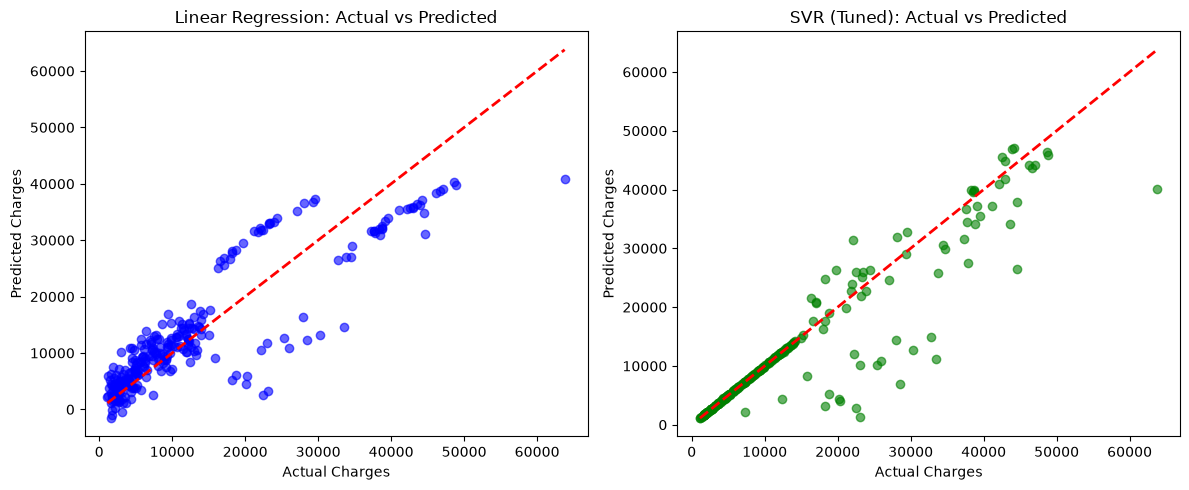

In [10]:
# Visualizations
plt.figure(figsize=(12, 5))

# Plot 1: Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

# Plot 2: SVR
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_svr, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('SVR (Tuned): Actual vs Predicted')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

plt.tight_layout()
plt.show()